# SRA(시냅틱 라우팅 아키텍처) 빠른 시작

본 노트북은 SRA의 기본 메커니즘과 주요 기능인 '라우팅' 동작을 쉽게 체험해 볼 수 있는 데모입니다.
Google Colab과 같은 환경에서는 위에서부터 순서대로 셀을 실행하는 것만으로도 SRA의 동작을 관찰할 수 있습니다.

## 1. 환경설정
Google Colab에서 실행하는 경우 다음 셀을 실행하여 저장소를 복제하고 필요한 라이브러리를 설치합니다.

In [1]:
# Run only in Colab environment (skip if local)
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

# Add path
sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. 라이브러리 가져오기 및 모델 준비
SRA MoE(전문가 혼합) 모델을 초기화합니다.

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model with a small configuration
config = MoESRAConfig(
    vocab_size=100,
    d_model=64,
    n_layers=2,
    n_heads=4,
    num_synapses=4,  # 4 experts (synapses)
    k=2,       # Select 2 synapses per token
    max_seq_len=64
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
print("Model initialized!")

Using device: cpu
Model initialized!


## 3. 더미 데이터를 이용한 포워드 패스 및 라우팅 확인
임의의 데이터를 입력하고 모델이 각 시냅스로 어떻게 라우팅되는지 확인합니다(전문가).

In [3]:
# Dummy data with batch size 2 and sequence length 10
x = torch.randint(0, config.vocab_size, (2, 10)).to(device)

model.eval()
with torch.no_grad():
    y_in = torch.cat([torch.full((x.size(0), 1), 1, dtype=torch.long, device=device), x[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
print("Output shape:", outputs.shape)
print("Number of layers with routing info:", len(routing_weights))

Output shape: torch.Size([2, 10, 100])
Number of layers with routing info: 2


## 4. 라우팅 시각화
특정 레이어에서 각 입력 토큰이 라우팅된 시냅스(전문가)를 히트맵으로 시각화합니다.
* 여기서는 훈련 전 무작위 상태의 라우팅을 보여줍니다.훈련이 진행되고 작업이 전문화됨에 따라 이 라우팅은 편향(전문화)을 보여줍니다.

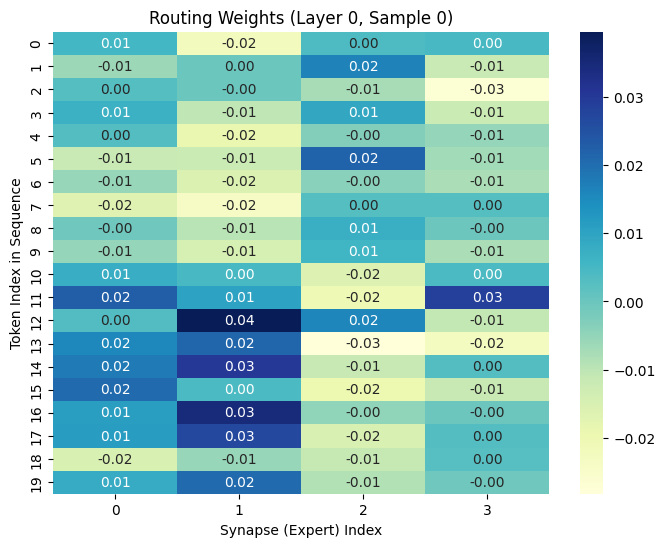

In [4]:
# Get routing weights of the first layer of the first sample
layer_idx = 0
sample_idx = 0
weights = routing_weights[layer_idx][sample_idx].cpu().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(weights, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title(f"Routing Weights (Layer {layer_idx}, Sample {sample_idx})")
plt.xlabel("Synapse (Expert) Index")
plt.ylabel("Token Index in Sequence")
plt.show()